In [60]:
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
import matplotlib
from PIL import Image

import matplotlib.animation as animation
from IPython.display import HTML

In [93]:
def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())
  
class BumpyTorus:
    def __init__(self, R=1.0, r=0.3, bump_amp=0.1, bump_freq=5):
        self.R = R
        self.r = r
        self.bump_amp = bump_amp
        self.bump_freq = bump_freq

    def rad(self, theta, phi):
        r_mod = self.r + self.bump_amp * np.sin(self.bump_freq * phi) * np.cos(self.bump_freq * theta)
        x = (self.R + r_mod * np.cos(phi)) * np.cos(theta)
        y = (self.R + r_mod * np.cos(phi)) * np.sin(theta)
        z = r_mod * np.sin(phi)
        return np.array([x, y, z])

    def surface_normal(self, theta, phi, delta=1e-5):
        p = self.rad(theta, phi)
        dp_dtheta = (self.rad(theta + delta, phi) - self.rad(theta - delta, phi)) / (2 * delta)
        dp_dphi = (self.rad(theta, phi + delta) - self.rad(theta, phi - delta)) / (2 * delta)
        normal = np.cross(dp_dtheta, dp_dphi)
        return normal / np.linalg.norm(normal)

    def generate_mesh(self, resolution=100):
        theta = np.linspace(0, 2 * np.pi, resolution)
        phi = np.linspace(0, 2 * np.pi, resolution)
        theta_grid, phi_grid = np.meshgrid(theta, phi)

        x = np.zeros_like(theta_grid)
        y = np.zeros_like(theta_grid)
        z = np.zeros_like(theta_grid)

        for i in range(resolution):
            for j in range(resolution):
                point = self.rad(theta_grid[i, j], phi_grid[i, j])
                x[i, j], y[i, j], z[i, j] = point

        return x, y, z

    def sample_surface_points(self, n_points=2, seed=None):
        if seed is not None:
            np.random.seed(seed)

        theta = np.random.uniform(0, 2 * np.pi, n_points)
        phi = np.random.uniform(0, 2 * np.pi, n_points)

        return [self.rad(t, p) for t, p in zip(theta, phi)]

    def sample_close_surface_points(self, epsilon=0.01, seed=None):
        if seed is not None:
            np.random.seed(seed)

        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, 2 * np.pi)

        dtheta = np.random.uniform(-epsilon, epsilon)
        dphi = np.random.uniform(-epsilon, epsilon)

        theta2 = np.mod(theta + dtheta, 2 * np.pi)
        phi2 = np.mod(phi + dphi, 2 * np.pi)

        p1 = self.rad(theta, phi)
        p2 = self.rad(theta2, phi2)
        return [p1, p2]

    def project_to_surface(self, point):
        """
        Approximate projection of a 3D point onto the bumpy torus surface.

        Parameters:
        - point: np.array([x, y, z])

        Returns:
        - np.array([x_proj, y_proj, z_proj]) on the surface
        """
        x, y, z = point
        theta = np.arctan2(y, x)
        xy_dist = np.sqrt(x**2 + y**2)
        local_r = xy_dist - self.R
        phi = np.arctan2(z, local_r)

        theta = np.mod(theta, 2 * np.pi)
        phi = np.mod(phi, 2 * np.pi)

        return self.rad(theta, phi)
    
    def theta_phi(self, point):
        """
        Approximate inverse mapping: convert 3D point to (theta, phi) angles.

        Parameters:
        - point: np.array([x, y, z])

        Returns:
        - theta: angle around the major circle [0, 2π]
        - phi: angle around the minor (tube) circle [0, 2π]
        """
        x, y, z = point
        theta = np.arctan2(y, x)  # angle around the z-axis

        # Position on the ring circle (major circle)
        xy_dist = np.sqrt(x**2 + y**2)
        local_x = xy_dist - self.R
        local_y = z

        phi = np.arctan2(local_y, local_x)

        theta = np.mod(theta, 2 * np.pi)
        phi = np.mod(phi, 2 * np.pi)

        return theta, phi
    
def set_axes_equal(ax):
    """
    Set equal aspect ratio in 3D plot — so that x, y, z units are the same.
    """
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    centers = np.mean(limits, axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

In [109]:
# Torus parameters
R = 2.0
r = 0.6
bump_amp = 0.2
bump_freq = 3

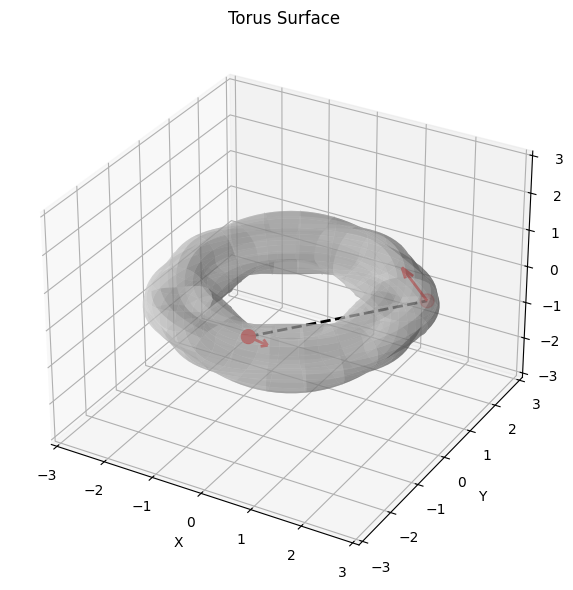

In [111]:
# Create torus and generate mesh
torus = BumpyTorus(R=R, r=r, bump_amp=bump_amp, bump_freq=bump_freq)
x, y, z = torus.generate_mesh(resolution=100)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

points = torus.sample_close_surface_points(epsilon=10, seed=None)
ax.scatter3D(*zip(*points), color='red', s=100)
ax.plot3D(*zip(*points), color='k', linewidth=2, linestyle='--')
normal_1 = -torus.surface_normal(*torus.theta_phi(points[0]))
normal_2 = -torus.surface_normal(*torus.theta_phi(points[1]))
ax.quiver(*points[0], *normal_1, color='red', length=1, linewidth=2)
ax.quiver(*points[1], *normal_2, color='red', length=1, linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Torus Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()

In [112]:
x1_init = points[0]
x2_init = points[1]
n1_init = -torus.surface_normal(*torus.theta_phi(x1_init))
n2_init = -torus.surface_normal(*torus.theta_phi(x2_init))
theta1_init = np.arccos((x2_init - x1_init).dot(n2_init) / np.linalg.norm(x2_init - x1_init))
theta2_init = np.arccos((x1_init - x2_init).dot(n1_init) / np.linalg.norm(x1_init - x2_init))

eta = 0.001

list_x1 = [x1_init.reshape(1, -1)]
list_x2 = [x2_init.reshape(1, -1)]
list_n1 = [n1_init.reshape(1, -1)]
list_n2 = [n2_init.reshape(1, -1)]
list_theta1 = [theta1_init]
list_theta2 = [theta2_init]

x1 = x1_init
x2 = x2_init
for iter_ in range(15000):
    n1 = -torus.surface_normal(*torus.theta_phi(x1))
    n2 = -torus.surface_normal(*torus.theta_phi(x2))   
    diff_vec = x2 - x1
    e = diff_vec / np.linalg.norm(diff_vec)
    theta1 = np.arccos((-e*n2).sum())
    theta2 = np.arccos((e*n1).sum())

    t1 = n2 - (n2*e).sum()*e
    t2 = n1 - (n1*e).sum()*e

    t1 = t1 - (t1*n1).sum()*n1
    t2 = t2 - (t2*n2).sum()*n2

    x1 = x1 + eta*t1
    x2 = x2 + eta*t2

    x1 = torus.project_to_surface(x1)
    x2 = torus.project_to_surface(x2)

    list_x1.append(x1.reshape(1, -1))
    list_x2.append(x2.reshape(1, -1))
    list_n1.append(n1.reshape(1, -1))
    list_n2.append(n2.reshape(1, -1))
    list_theta1.append(theta1)
    list_theta2.append(theta2)

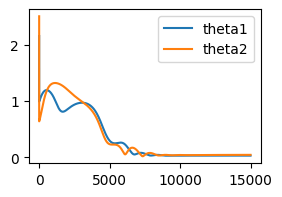

In [113]:
# plot theta as a function for iterations
plt.figure(figsize=(3, 2))
plt.plot(list_theta1, label='theta1')
plt.plot(list_theta2, label='theta2')
plt.legend()
plt.show()

In [114]:
X1_original = np.concatenate(list_x1, axis=0)
X2_original = np.concatenate(list_x2, axis=0)
N1_original = np.concatenate(list_n1, axis=0)
N2_original = np.concatenate(list_n2, axis=0)
THETA1_original = np.array(list_theta1)
THETA2_original = np.array(list_theta2)

In [115]:
video = []
skip_frame = 150
for k, (x1, x2, n1, n2, theta1, theta2) in enumerate(zip(
    X1_original[::skip_frame], 
    X2_original[::skip_frame], 
    N1_original[::skip_frame], 
    N2_original[::skip_frame], 
    THETA1_original[::skip_frame], 
    THETA2_original[::skip_frame]
)):
    torus = BumpyTorus(R=R, r=r, bump_amp=bump_amp, bump_freq=bump_freq)
    x, y, z = torus.generate_mesh(resolution=100)

    # Plot with matplotlib
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

    if (theta1 < 5*np.pi/180) and (theta2 < 5*np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(*zip(x1, x2), color=color, s=100)
    if color == 'green':
        ax.plot3D(*zip(x1, x2), color=color, linewidth=2, linestyle='--')
    else:
        ax.plot3D(*zip(x1, x2), color='k', linewidth=2, linestyle='--')
    ax.quiver(*x1, *n1, color=color, length=1, linewidth=2)
    ax.quiver(*x2, *n2, color=color, length=1, linewidth=2)
    set_axes_equal(ax)
    
    # add title with theta 1 and theta 2
    ax.set_title(f'Theta1: {theta1*180/np.pi:.2f} deg, Theta2: {theta2*180/np.pi:.2f} deg')

    buf = BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)  
    plt.close()
    video.append(np.array(Image.open(buf)))

In [116]:
display_video(video, framerate=30)

## Drawing a figure

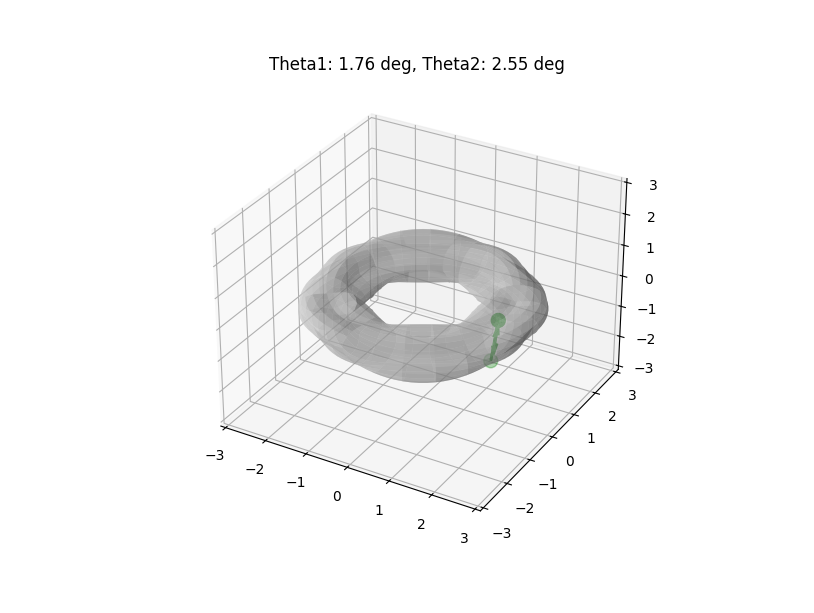

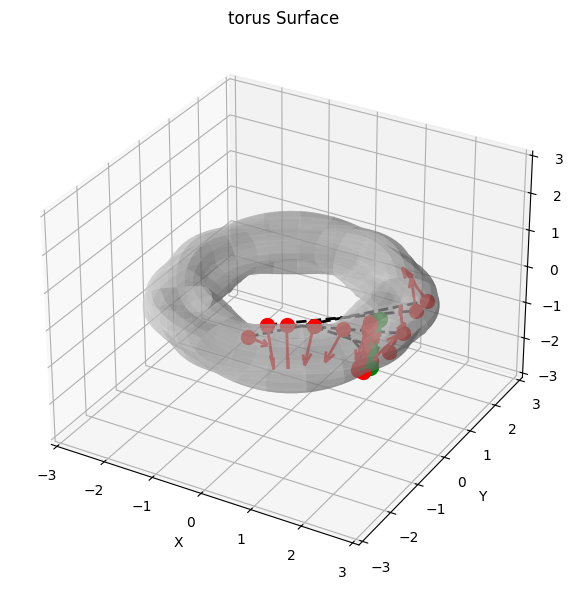

In [118]:
# slicing
X1 = X1_original[::1000]
X2 = X2_original[::1000]
N1 = N1_original[::1000]
N2 = N2_original[::1000]
THETA1 = THETA1_original[::1000]
THETA2 = THETA2_original[::1000]

# Create torus and generate mesh
torus = BumpyTorus(R=R, r=r, bump_amp=bump_amp, bump_freq=bump_freq)
x, y, z = torus.generate_mesh(resolution=100)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

# plot line conntecting X1 and X2
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'k'
    ax.plot3D([X1[i, 0], X2[i, 0]], [X1[i, 1], X2[i, 1]], [X1[i, 2], X2[i, 2]], color=color, linewidth=2, linestyle='--')
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.quiver(X1[i, 0], X1[i, 1], X1[i, 2], N1[i, 0], N1[i, 1], N1[i, 2], color=color, length=1, linewidth=2)
    ax.quiver(X2[i, 0], X2[i, 1], X2[i, 2], N2[i, 0], N2[i, 1], N2[i, 2], color=color, length=1, linewidth=2)

# scatter with different color
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(X1[i, 0], X1[i, 1], X1[i, 2], color=color, s=100)
    ax.scatter3D(X2[i, 0], X2[i, 1], X2[i, 2], color=color, s=100)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('torus Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()